# Hypothesis testing

In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import norm
import scipy.stats as st

In [53]:
heights = pd.read_csv('Data/heights.dat')

In [54]:
heights

,Height
0,156
1,163
2,169
3,161
4,154
...,...
346,159
347,170
348,160
349,152


(array([ 1.,  3.,  5.,  3.,  6., 18., 28., 41., 51., 17., 41., 48., 35.,
        18.,  6., 19.,  3.,  4.,  1.,  3.]),
 array([142. , 143.8, 145.6, 147.4, 149.2, 151. , 152.8, 154.6, 156.4,
        158.2, 160. , 161.8, 163.6, 165.4, 167.2, 169. , 170.8, 172.6,
        174.4, 176.2, 178. ]),
 <BarContainer object of 20 artists>)

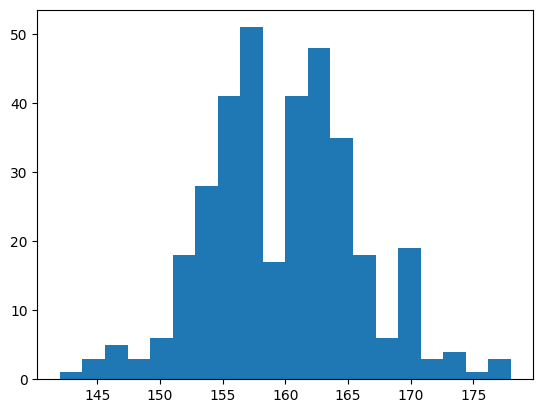

In [55]:
plt.hist(heights.Height, bins=20)

(array([ 1.,  4.,  6.,  7., 35., 32., 40., 48., 59., 47., 29., 13., 22.,
         3.,  1.,  4.]),
 array([142.  , 144.25, 146.5 , 148.75, 151.  , 153.25, 155.5 , 157.75,
        160.  , 162.25, 164.5 , 166.75, 169.  , 171.25, 173.5 , 175.75,
        178.  ]),
 <BarContainer object of 16 artists>)

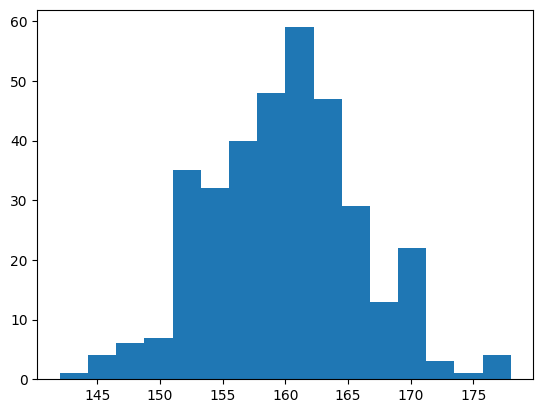

In [56]:
plt.hist(heights.Height, bins='fd')

In [57]:
norm.pdf(0, loc = 0, scale = 1 )

np.float64(0.3989422804014327)

In [58]:
x = np.linspace(130, 190, 1000)
probabilities = norm.pdf(x, loc = 160, scale = 5)
probabilities2 = norm.pdf(x, loc = 155, scale = 10)

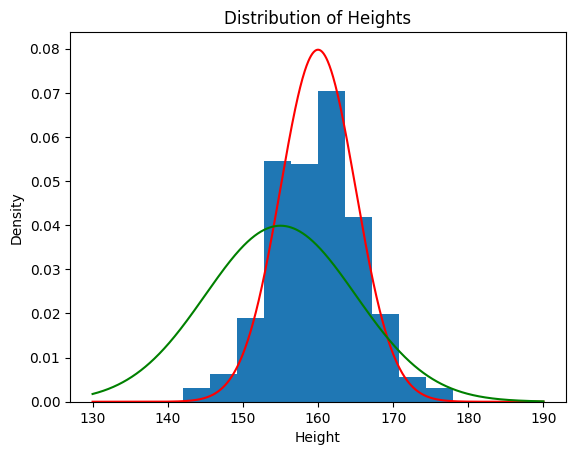

In [59]:
plt.hist(heights.Height, bins =10, density = True)
plt.xlabel('Height')
plt.plot(x, probabilities, c='red')
plt.plot(x, probabilities2, c='green')
plt.ylabel('Density')
plt.title('Distribution of Heights')
plt.show()

In [60]:
heights.Height.describe()

count    351.000000
mean     159.774929
std        6.029740
min      142.000000
25%      156.000000
50%      160.000000
75%      164.000000
max      178.000000
Name: Height, dtype: float64

In [61]:
lower_bound = 145
upper_bound = 165

sum((heights.Height >= lower_bound) & (heights.Height <= upper_bound)) / len(heights)

0.8433048433048433

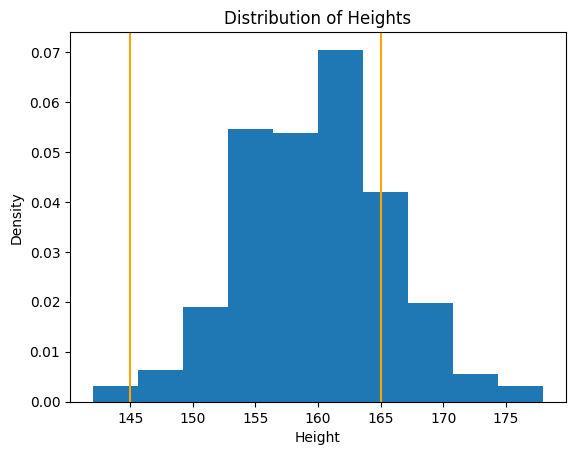

In [62]:
plt.hist(heights.Height, bins =10, density = True)
plt.xlabel('Height')
plt.axvline(lower_bound, c='orange', label='Lower bound')
plt.axvline(upper_bound, c='orange', label='Upper bound')
#plt.plot(x, probabilities, c='red')
#plt.plot(x, probabilities2, c='green')
plt.ylabel('Density')
plt.title('Distribution of Heights')
plt.show()

In [63]:
norm.cdf(upper_bound, loc = 160, scale = 5) 

np.float64(0.8413447460685429)

In [64]:
norm.cdf(lower_bound, loc = 160, scale = 5) 

np.float64(0.001349898031630093)

In [65]:
norm.cdf(upper_bound, loc = 160, scale = 5) - norm.cdf(lower_bound, loc = 160, scale = 5)

np.float64(0.8399948480369128)

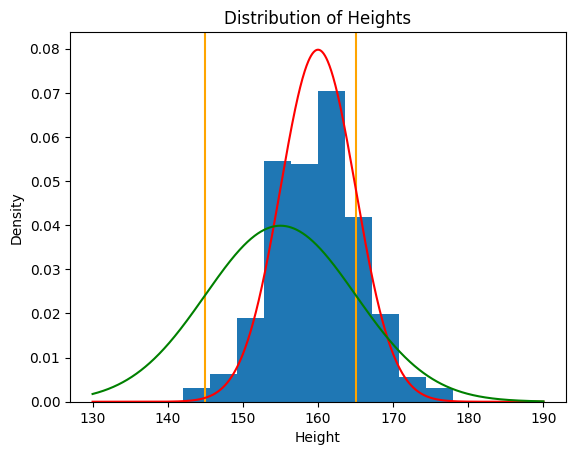

In [66]:
plt.hist(heights.Height, bins =10, density = True)
plt.xlabel('Height')
plt.axvline(lower_bound, c='orange', label='Lower bound')
plt.axvline(upper_bound, c='orange', label='Upper bound')
plt.plot(x, probabilities, c='red')
plt.plot(x, probabilities2, c='green')
plt.ylabel('Density')
plt.title('Distribution of Heights')
plt.show()

In [67]:
norm.ppf(0.857, loc = 159.774929, scale = 6.029749)

np.float64(166.20829512077668)

In [68]:
norm.cdf(166.20829512077668, loc = 159.774929, scale = 6.029749)

np.float64(0.857)

In [69]:
upper_theoretical_bound = norm.ppf(0.975, loc = 159.774929, scale = 6.029749)
lower_theoretical_bound = norm.ppf(0.025, loc = 159.774929, scale = 6.029749)

In [70]:
norm.cdf(upper_theoretical_bound, loc = 159.774929, scale = 6.029749) - norm.cdf(lower_theoretical_bound, loc = 159.774929, scale = 6.029749)

np.float64(0.9500000000000002)

In [71]:
lower_theoretical_bound, upper_theoretical_bound

(np.float64(147.95683812418358), np.float64(171.5930198758164))

In [72]:
confidence_level = 0.95
remaining = 1 - confidence_level

In [73]:
upper_theoretical_bound2 = norm.ppf(confidence_level + (remaining/2), loc = 159.774929, scale = 6.029749)
lower_theoretical_bound2 = norm.ppf(remaining/2, loc = 159.774929, scale = 6.029749)

In [74]:
upper_theoretical_bound2, lower_theoretical_bound2

(np.float64(171.5930198758164), np.float64(147.95683812418358))

## Hypothesis Testing

In [75]:
norm.rvs(loc = 500, scale = 50)

np.float64(541.2909849212797)

In [78]:
population = norm.rvs(loc = 500, scale = 50, size = 100000)

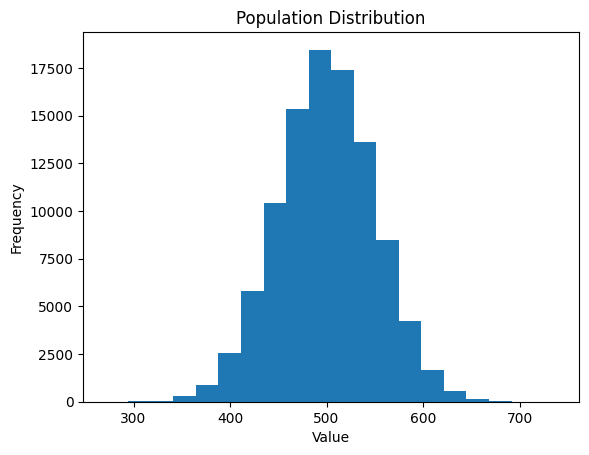

In [79]:
plt.hist(population, bins = 20)
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Population Distribution')
plt.show()

In [80]:
np.random.choice(population, size = 25)

array([416.94460611, 566.51705415, 609.48665096, 463.41396062,
       516.94398035, 423.0030476 , 485.96333525, 396.89892722,
       390.9461403 , 384.20921897, 541.25249549, 413.81432308,
       519.38642462, 513.12654038, 472.63119156, 510.45659899,
       473.84022127, 516.87023326, 432.75543403, 525.5769793 ,
       561.66989325, 456.82120414, 479.71600428, 454.55767458,
       492.48690911])

In [81]:
sample_size = 25
sample = [np.random.choice(population, size = sample_size) for experiment in range(100)]

In [82]:
sample

[array([522.2050878 , 541.89063883, 519.96516977, 470.66333013,
        473.66879591, 538.30298532, 485.30607247, 512.49951226,
        534.35252164, 595.77748985, 497.94244613, 483.02985198,
        560.65837064, 543.46601885, 480.03567963, 428.24689322,
        458.6474653 , 449.42480119, 514.5076672 , 466.6099702 ,
        496.62197616, 424.21260356, 572.60641549, 533.82215821,
        474.83791329]),
 array([541.09828419, 556.94538595, 482.50858258, 495.78875656,
        386.94369584, 463.75105805, 497.88296337, 486.18478304,
        535.02528575, 499.51414614, 532.96120952, 438.78799555,
        543.69224948, 600.99528576, 524.41720195, 479.4718647 ,
        496.45306721, 484.00816994, 512.59601407, 436.48803465,
        494.27589877, 495.02033216, 503.62367328, 432.38116953,
        468.57741896]),
 array([548.21798336, 546.87512961, 523.75725411, 469.90503554,
        431.17945089, 612.32014487, 521.25200465, 510.40773862,
        432.22472445, 593.13345301, 527.81350839, 482.46

In [83]:
[sample.mean() for sample in sample]

[np.float64(503.17207340156847),
 np.float64(495.5757010806824),
 np.float64(496.2238336338654),
 np.float64(499.9435087199812),
 np.float64(493.7626853756992),
 np.float64(501.78054575065784),
 np.float64(513.1767559867396),
 np.float64(495.15992638828806),
 np.float64(502.30076927022884),
 np.float64(520.9858020164534),
 np.float64(487.1301734760002),
 np.float64(478.8988019753724),
 np.float64(508.27227537170756),
 np.float64(491.80408959458487),
 np.float64(496.81198779944594),
 np.float64(517.64580630846),
 np.float64(504.8627766209331),
 np.float64(513.9580432586924),
 np.float64(502.8327227712775),
 np.float64(511.6254846317588),
 np.float64(518.1983335252351),
 np.float64(501.94598000796447),
 np.float64(487.67478371103897),
 np.float64(484.95381461908823),
 np.float64(484.4444641487203),
 np.float64(498.32758024299926),
 np.float64(517.6234413629702),
 np.float64(488.87408423996834),
 np.float64(507.5772953873566),
 np.float64(515.9712504701031),
 np.float64(481.03302158243406

In [84]:
sample_means = [sample.mean() for sample in sample]

In [85]:
mean_of_means = np.mean(sample_means)

In [86]:
mean_of_means

np.float64(499.96351822340307)

In [87]:
np.std(sample_means, ddof=1)

np.float64(11.195019798984873)

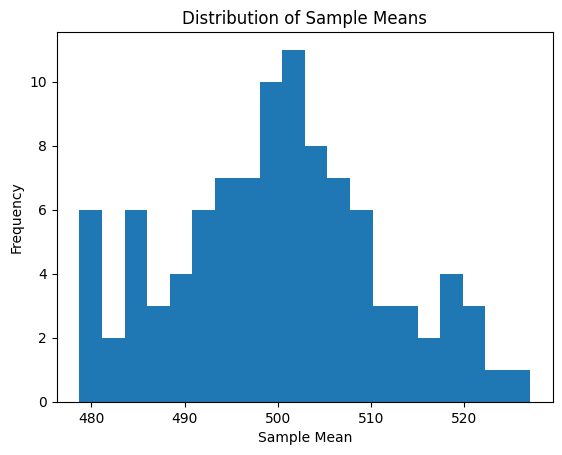

In [89]:
plt.hist(sample_means, bins = 20)
plt.xlabel('Sample Mean')
plt.ylabel('Frequency')
plt.title('Distribution of Sample Means')
plt.show()

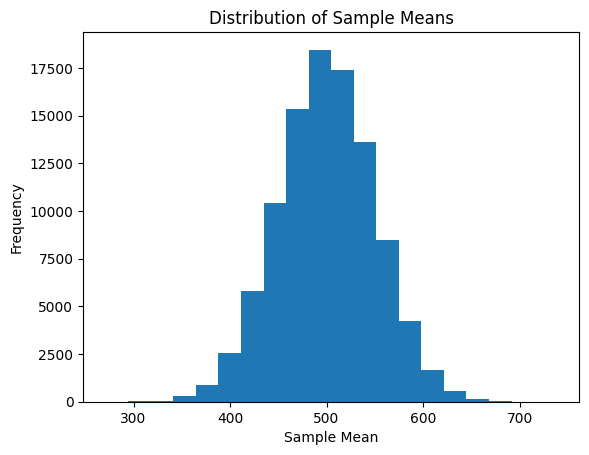

In [91]:
plt.hist(population, bins = 20,)
plt.hist(sample_means, bins = 20)
plt.xlabel('Sample Mean')
plt.ylabel('Frequency')
plt.title('Distribution of Sample Means')
plt.show()

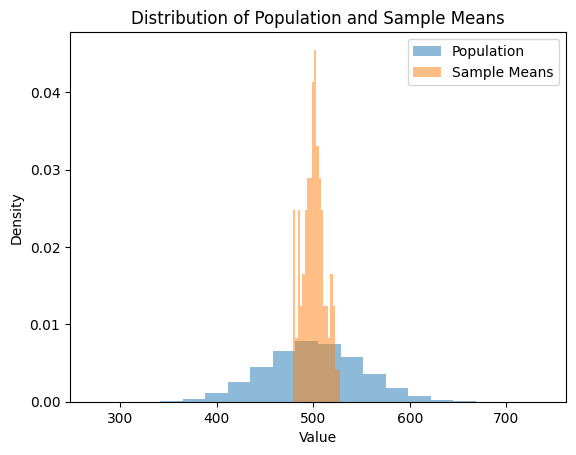

In [92]:
plt.hist(population, bins = 20, density=True, alpha=0.5, label='Population')
plt.hist(sample_means, bins = 20, density=True, alpha=0.5, label='Sample Means')
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Distribution of Population and Sample Means')
plt.legend()
plt.show()

In [93]:
population_mean = 500
population_std = 50
population = norm.rvs(loc = population_mean, scale = population_std, size = 100000)

In [95]:
population_std / np.sqrt(sample_size)

np.float64(10.0)

In [97]:
st.ttest_1samp(heights.Height, popmean=140)

TtestResult(statistic=np.float64(61.44264023189489), pvalue=np.float64(1.4381406384802715e-189), df=np.int64(350))

In [99]:
st.ttest_1samp(heights.Height, popmean=187)

TtestResult(statistic=np.float64(-84.59096240541525), pvalue=np.float64(4.5609159401491904e-235), df=np.int64(350))

In [100]:
len(heights)

351

In [103]:
grain_data = pd.read_table('Data/grain_data.dat')

In [104]:
grain_data

,Year,GreatNorthern,BigFour
0,1912,71.0,54.7
1,1913,73.9,60.6
2,1914,48.9,45.1
3,1915,78.9,71.0
4,1916,43.5,40.9
5,1917,47.9,45.4
6,1918,63.0,53.4
7,1919,48.4,41.2
8,1920,48.1,44.8


In [116]:
st.ttest_ind(grain_data.GreatNorthern, grain_data.BigFour).pvalue * 100

np.float64(20.792200785311792)

In [117]:
grain_data.GreatNorthern.mean(), grain_data.BigFour.mean()

(np.float64(58.17777777777778), np.float64(50.788888888888884))

In [108]:
water_data = pd.read_csv('Data/water_data.dat')

In [109]:
water_data

,bottom\tsurface
0,0.43\t0.415
1,0.266\t0.238
2,0.567\t0.39
3,0.531\t0.41
4,0.707\t0.605
5,0.716\t0.609
6,0.651\t0.632
7,0.589\t0.523
8,0.469\t0.411
9,0.723\t0.612


In [110]:
water_data = pd.read_table('Data/water_data.dat')

In [111]:
water_data

,bottom,surface
0,0.430,0.415
1,0.266,0.238
2,0.567,0.390
3,0.531,0.410
4,0.707,0.605
5,0.716,0.609
6,0.651,0.632
7,0.589,0.523
8,0.469,0.411
9,0.723,0.612


In [113]:
st.ttest_rel(water_data.bottom, water_data.surface)

TtestResult(statistic=np.float64(4.863812745135183), pvalue=np.float64(0.0008911154578225482), df=np.int64(9))

In [114]:
st.ttest_rel(water_data.bottom, water_data.surface).pvalue * 100

np.float64(0.08911154578225482)

In [115]:
water_data.bottom.mean(), water_data.surface.mean() 

(np.float64(0.5649), np.float64(0.4845))

In [119]:
st.chi2_contingency([[10, 20], [30, 40]])

Chi2ContingencyResult(statistic=np.float64(0.4464285714285714), pvalue=np.float64(0.5040358664525046), dof=1, expected_freq=array([[12., 18.],
       [28., 42.]]))

In [120]:
st.f_oneway(grain_data.GreatNorthern, grain_data.BigFour)

F_onewayResult(statistic=np.float64(1.7222276311946256), pvalue=np.float64(0.207922007853118))